In [87]:
import pandas as pd
import matplotlib.pyplot as plt

In [88]:
df = pd.read_csv('/content/netflix_titles.csv')

In [89]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [90]:
# First let us identify the missing values in each column

df.isna().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [91]:
# remove identical or duplicate rows

df = df.drop_duplicates()

In [92]:
df['rating'].value_counts()

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


In [93]:
# 74 min, 84 min, 66 min, replace this ratings with unknown

df['rating'] = df['rating'].replace(['74 min', '84 min', '66 min'], 'Unknown')

df['rating'] = df['rating'].fillna('Unknown')

In [94]:
# count how many movies and tv shows are there

type_counts = df['type'].value_counts()
type_counts

,count
type,
Movie,6131
TV Show,2676


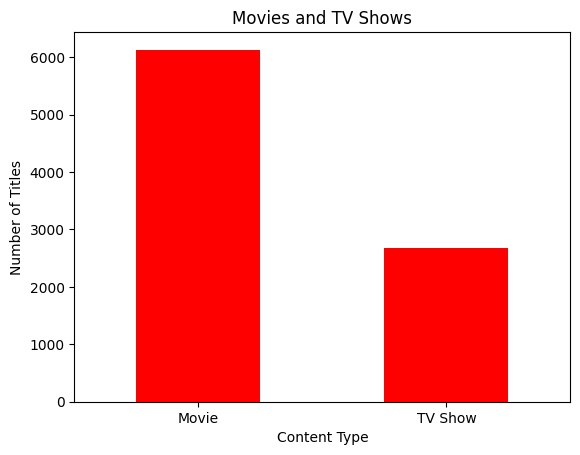


Movies are more common than TV shows in this dataset: 6,131 movies compared with 2,676 TV shows.


In [95]:
# draw a chart

type_counts.plot(kind='bar', color='red')

plt.title('Movies and TV Shows')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)


plt.show()
print('')
print('Movies are more common than TV shows in this dataset: 6,131 movies compared with 2,676 TV shows.')

In [96]:
# Find the most common genres and categories

genres = df['listed_in'].str.split(',')
genres

# this splits the text at each comma

,listed_in
0,[Documentaries]
1,"[International TV Shows, TV Dramas, TV Myste..."
2,"[Crime TV Shows, International TV Shows, TV ..."
3,"[Docuseries, Reality TV]"
4,"[International TV Shows, Romantic TV Shows, ..."
...,...
8802,"[Cult Movies, Dramas, Thrillers]"
8803,"[Kids' TV, Korean TV Shows, TV Comedies]"
8804,"[Comedies, Horror Movies]"
8805,"[Children & Family Movies, Comedies]"


In [97]:
#puts each category on its own row

genres = genres.explode()
genres

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
2,Crime TV Shows
...,...
8805,Children & Family Movies
8805,Comedies
8806,Dramas
8806,International Movies


In [98]:
# removes extra spaces around the category names

genres = genres.str.strip()
genres

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
2,Crime TV Shows
...,...
8805,Children & Family Movies
8805,Comedies
8806,Dramas
8806,International Movies


In [99]:
# now lets count the genres

genre_counts = genres.value_counts().head(10)
genre_counts

,count
listed_in,
International Movies,2752
Dramas,2427
Comedies,1674
International TV Shows,1351
Documentaries,869
Action & Adventure,859
TV Dramas,763
Independent Movies,756
Children & Family Movies,641


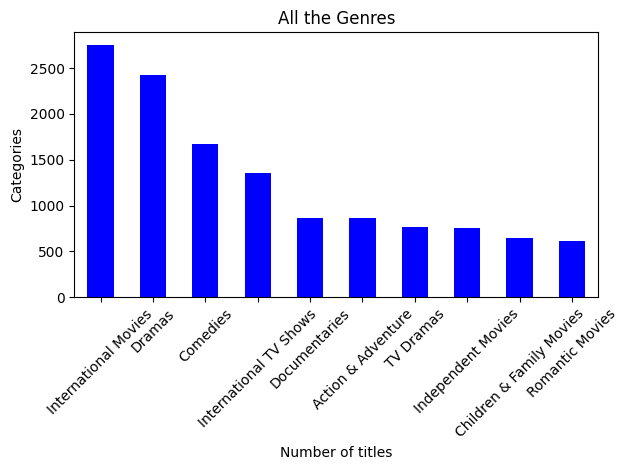


International Movies, Dramas and Comedies are the three most common categories in the dataset.


In [100]:
# now let us draw the chart for this

genre_counts.plot(kind='bar', color='blue')

plt.title('All the Genres')
plt.xlabel('Number of titles')
plt.ylabel('Categories')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print('')
print('International Movies, Dramas and Comedies are the three most common categories in the dataset.')

In [101]:
# exploring the maturity ratings

ratings_count = df['rating'].value_counts()
ratings_count

,count
rating,
TV-MA,3207
TV-14,2160
TV-PG,863
R,799
PG-13,490
TV-Y7,334
TV-Y,307
PG,287
TV-G,220


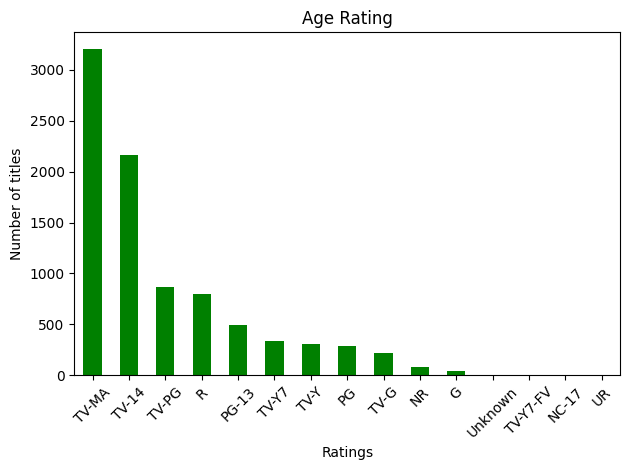


TV-MA is the most common maturity classification, appearing on 3,207 titles.


In [102]:
ratings_count.plot(kind='bar', color='green')

plt.title('Age Rating')
plt.xlabel('Ratings')
plt.ylabel('Number of titles')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print('')
print('TV-MA is the most common maturity classification, appearing on 3,207 titles.')



In [103]:
year_counts = df['release_year'].value_counts()
year_counts

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902
...,...
1961,1
1925,1
1959,1


In [104]:
# put the years in chronological order

year_counts = year_counts.sort_index()
year_counts

,count
release_year,
1925,1
1942,2
1943,3
1944,3
1945,4
...,...
2017,1032
2018,1147
2019,1030


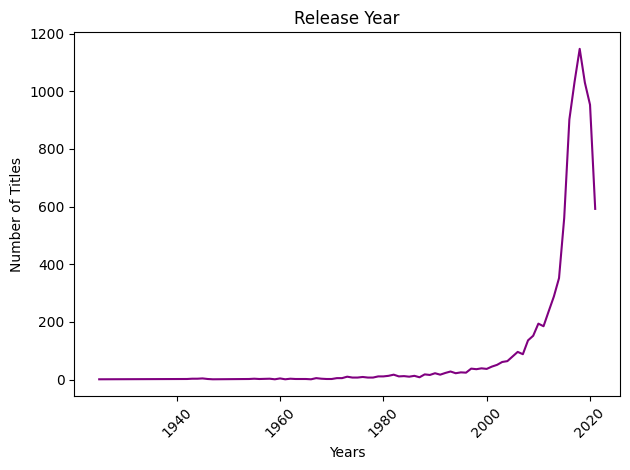

 
Among the titles in this dataset, 2018 is the most represented release year, with 1,147 titles.


In [105]:
# draw a line chart for this

year_counts.plot(kind='line', color='purple')
plt.title('Release Year')
plt.xlabel('Years')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

print(' ')
print('Among the titles in this dataset, 2018 is the most represented release year, with 1,147 titles.')

In [106]:
df['release_year'].value_counts().head(5)

,count
release_year,
2018,1147
2017,1032
2019,1030
2020,953
2016,902


In [107]:
df['country'].isna().sum()

np.int64(831)

In [108]:
countries= df['country'].dropna()
countries

,country
0,United States
1,South Africa
4,India
7,"United States, Ghana, Burkina Faso, United Kin..."
8,United Kingdom
...,...
8801,"United Arab Emirates, Jordan"
8802,United States
8804,United States
8805,United States


In [109]:
countries = countries.str.split(',')
countries = countries.explode()
countries = countries.str.strip()

In [110]:
country_counts = countries.value_counts().head(10).sort_values(ascending=True)
country_counts

,count
country,
Mexico,169
Germany,226
South Korea,231
Spain,232
Japan,318
France,393
Canada,445
United Kingdom,806
India,1046


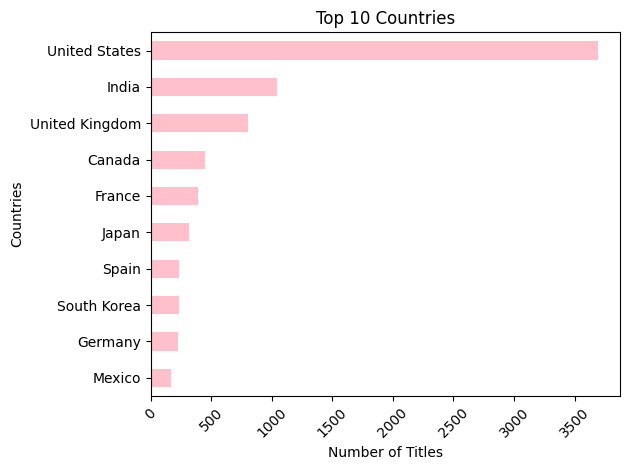

 
United States has the most amount of titles in this dataset


In [111]:
country_counts.plot(kind='barh', color='pink')
plt.title('Top 10 Countries')
plt.xlabel('Number of Titles')
plt.ylabel('Countries')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()
print(' ')
print('United States has the most amount of titles in this dataset')

This project explored 8,807 Netflix movie and TV-show records using pandas and Matplotlib. Movies outnumber TV shows. International Movies is the most common supplied category, and TV-MA is the most frequent maturity classification. The United States is associated with the most titles, while 2018 is the most represented release year.
These findings describe a historical dataset, with recorded additions through September 2021. They do not show Netflix’s current catalogue or which titles people watched most.